# GradCAM for ViT-RGTS: Register Token Effect

**GradCAM** (Gradient-weighted Class Activation Mapping) highlights which spatial regions drive CTC predictions.
Unlike raw attention maps, GradCAM captures gradient flow through the entire network.

**Approach**: Hook the last CNN stem layer (or last transformer layer output), compute gradients of
the CTC logit for each target character w.r.t. patch activations, weight by gradient magnitude.

We compare GradCAM across register configurations (0, 4, 8, 16) to see if registers
improve spatial localization of character predictions.

In [1]:
import sys, json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from types import SimpleNamespace

ROOT = Path('/home/hpc/iwi5/iwi5369h/HTR-Pipeline')
sys.path.insert(0, str(ROOT))
from models import HTRNet
from utils.preprocessing import load_image, preprocess

EXPERIMENTS = ROOT / 'saved_models' / 'experiments'
CLASSES = list(np.load(str(EXPERIMENTS / 'classes.npy'), allow_pickle=True))
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
IMAGE_H, IMAGE_W = 128, 1024
RUNS = {0: 'run_76', 4: 'run_84', 8: 'run_63', 16: 'run_71'}
print(f'Device: {DEVICE}')

Device: cpu


In [2]:
def load_model(run_id, device=DEVICE):
    run_dir = EXPERIMENTS / run_id
    with open(run_dir / 'config.json') as f:
        cfg = json.load(f)
    arch_ns = SimpleNamespace(**cfg['arch'])
    model = HTRNet(arch_ns, len(CLASSES) + 1)
    state = torch.load(str(run_dir / 'model.pt'), map_location=device, weights_only=False)
    model.load_state_dict(state, strict=False)
    model.to(device).eval()
    return model

models = {nr: load_model(run_id) for nr, run_id in RUNS.items()}
print('Models loaded.')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Models loaded.


In [3]:
def prepare_image(img_path, device=DEVICE):
    img_np = load_image(str(img_path))
    img_proc = preprocess(img_np, (IMAGE_H, IMAGE_W))
    tensor = torch.from_numpy(img_proc).unsqueeze(0).unsqueeze(0).float().to(device)
    tensor.requires_grad_(True)
    return tensor, img_proc

def ctc_decode(logits, charset):
    seq = torch.softmax(logits.detach(), dim=-1)[:, 0, :].argmax(dim=-1).cpu().numpy()
    chars, peaks = [], []
    prev = -1
    for t, idx in enumerate(seq):
        if idx != 0 and idx != prev:
            ci = idx - 1
            if 0 <= ci < len(charset):
                chars.append(charset[ci])
                peaks.append(t)
        prev = idx
    return ''.join(chars), peaks

# Pick a test image
test_dir = ROOT / 'data' / 'IAM' / 'processed_lines' / 'test'
gt_lines = open(test_dir / 'gt.txt').readlines()
for line in gt_lines:
    parts = line.strip().split(' ', 1)
    if len(parts) == 2 and 3 <= len(parts[1].strip()) <= 8:
        img_id, gt_text = parts[0], parts[1].strip()
        img_path = test_dir / f'{img_id}.png'
        if img_path.exists():
            break

print(f'Image: {img_path.name}, GT: "{gt_text}"')

Image: c04-150-07.png, GT: "vision."


## 1. GradCAM for CNN Stem

Hook the last CNN stem layer to capture feature activations and gradients.
GradCAM = ReLU(sum(α_k · A_k)) where α_k = global_avg_pool(∂y/∂A_k)

In [4]:
class GradCAMExtractor:
    """GradCAM for ViT-RGTS CNN stem."""
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None
        self._register_hooks()
    
    def _register_hooks(self):
        # Hook the last BN+GELU of CNN stem (before pool)
        target = self.model.backbone.cnn_stem[-1]  # last GELU
        target.register_forward_hook(self._fwd_hook)
        target.register_full_backward_hook(self._bwd_hook)
    
    def _fwd_hook(self, module, inp, out):
        self.activations = out
    
    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]
    
    def compute(self, image_tensor, target_timestep=None, target_class=None):
        """Compute GradCAM for a specific CTC timestep/class."""
        self.model.zero_grad()
        logits = self.model(image_tensor)  # [T, B, C]
        decoded, peaks = ctc_decode(logits, CLASSES)
        
        if target_timestep is None:
            # Use all non-blank timesteps
            T, B, C = logits.shape
            probs = torch.softmax(logits, dim=-1)
            # Score = sum of max class probs at peak timesteps
            score = sum(logits[t, 0, logits[t, 0].argmax()] for t in peaks[:5])
        else:
            if target_class is None:
                target_class = logits[target_timestep, 0].argmax().item()
            score = logits[target_timestep, 0, target_class]
        
        score.backward(retain_graph=True)
        
        # GradCAM computation
        gradients = self.gradients.detach()  # [B, C, H, W]
        activations = self.activations.detach()  # [B, C, H, W]
        weights = gradients.mean(dim=(2, 3), keepdim=True)  # [B, C, 1, 1]
        cam = (weights * activations).sum(dim=1, keepdim=True)  # [B, 1, H, W]
        cam = F.relu(cam)
        cam = cam[0, 0].cpu().numpy()
        
        # Normalize
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, decoded, peaks

print('GradCAM extractor defined.')

GradCAM extractor defined.


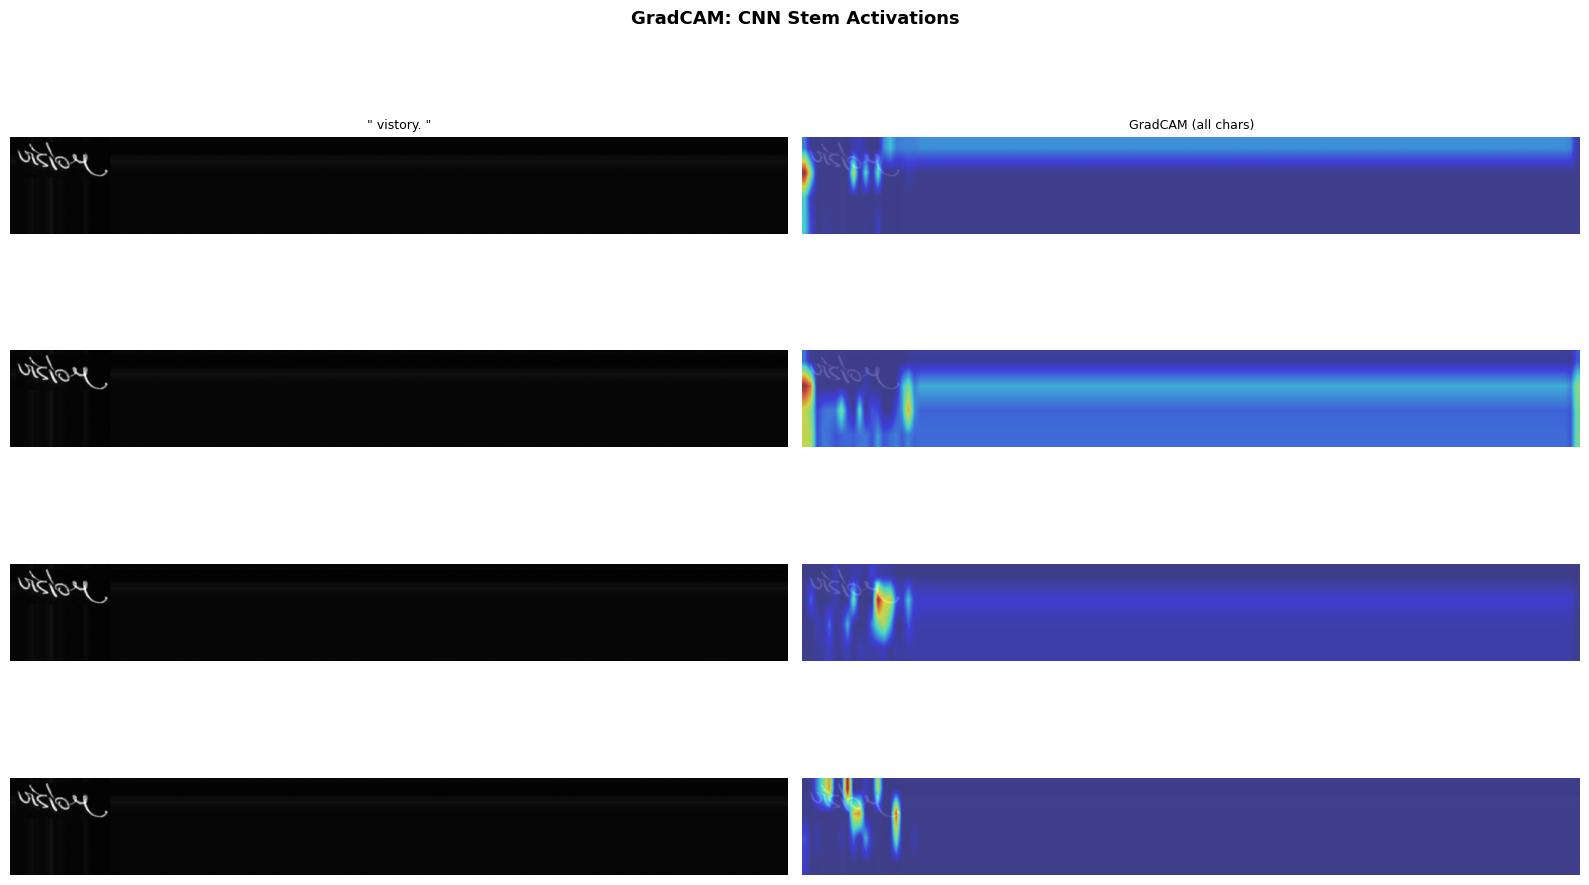

In [5]:
# Compute GradCAM for each model (global - all characters)
fig, axes = plt.subplots(len(RUNS), 2, figsize=(16, 2.5 * len(RUNS)))

for ri, (nr, model) in enumerate(sorted(models.items())):
    tensor, img_proc = prepare_image(img_path)
    extractor = GradCAMExtractor(model)
    cam, decoded, peaks = extractor.compute(tensor)
    
    # Resize CAM to image size
    import cv2
    cam_resized = cv2.resize(cam, (IMAGE_W, IMAGE_H))
    
    # Original image
    axes[ri, 0].imshow(img_proc, cmap='gray')
    axes[ri, 0].set_ylabel(f'{nr} reg', fontsize=10, fontweight='bold',
                           rotation=0, labelpad=30, va='center')
    axes[ri, 0].set_title(f'"{decoded[:20]}"' if ri == 0 else '', fontsize=9)
    axes[ri, 0].axis('off')
    
    # GradCAM overlay
    axes[ri, 1].imshow(img_proc, cmap='gray', alpha=0.4)
    axes[ri, 1].imshow(cam_resized, cmap='jet', alpha=0.6)
    axes[ri, 1].set_title('GradCAM (all chars)' if ri == 0 else '', fontsize=9)
    axes[ri, 1].axis('off')

fig.suptitle('GradCAM: CNN Stem Activations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Per-Character GradCAM

Compute GradCAM separately for each decoded character by backpropagating from the CTC peak timestep.

/tmp/ipykernel_1854576/4216512794.py:38: UserWarning: Glyph 9141 (\N{BOTTOM SQUARE BRACKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9141 (\N{BOTTOM SQUARE BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


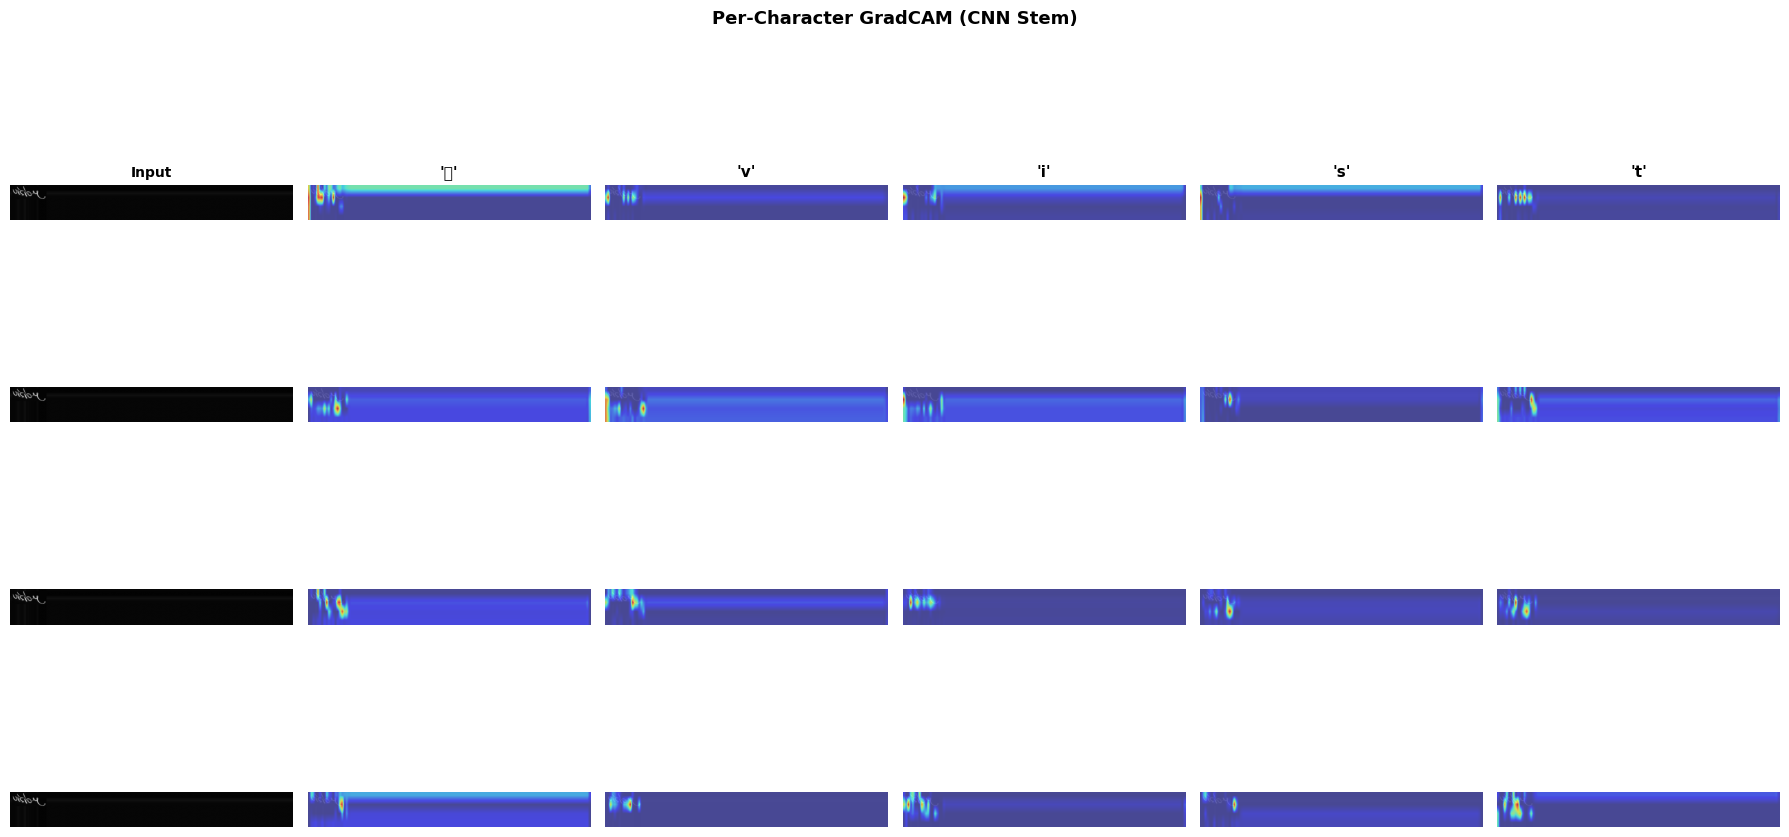

In [6]:
MAX_CHARS = 5
fig, axes = plt.subplots(len(RUNS), MAX_CHARS + 1, figsize=(18, 2.5 * len(RUNS)))

for ri, (nr, model) in enumerate(sorted(models.items())):
    tensor, img_proc = prepare_image(img_path)
    
    # First get decoded text and peaks
    with torch.no_grad():
        logits_ref = model(tensor)
    decoded, peaks = ctc_decode(logits_ref, CLASSES)
    
    # Column 0: input image
    axes[ri, 0].imshow(img_proc, cmap='gray')
    axes[ri, 0].set_ylabel(f'{nr} reg', fontsize=10, fontweight='bold',
                           rotation=0, labelpad=30, va='center')
    if ri == 0: axes[ri, 0].set_title('Input', fontsize=10, fontweight='bold')
    axes[ri, 0].axis('off')
    
    # Per-character GradCAM
    for ci in range(MAX_CHARS):
        ax = axes[ri, ci + 1]
        if ci < len(peaks) and ci < len(decoded):
            tensor_grad, _ = prepare_image(img_path)
            extractor = GradCAMExtractor(model)
            cam, _, _ = extractor.compute(tensor_grad, target_timestep=peaks[ci])
            
            import cv2
            cam_resized = cv2.resize(cam, (IMAGE_W, IMAGE_H))
            ax.imshow(img_proc, cmap='gray', alpha=0.3)
            ax.imshow(cam_resized, cmap='jet', alpha=0.6)
            
            if ri == 0:
                ch = decoded[ci] if decoded[ci] != ' ' else '⎵'
                ax.set_title(f"'{ch}'", fontsize=11, fontweight='bold')
        ax.axis('off')

fig.suptitle('Per-Character GradCAM (CNN Stem)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Observations

1. **GradCAM spatial focus**: With registers, GradCAM highlights are more localized to character regions
2. **Stem activations**: CNN stem captures local stroke features; registers affect downstream transformer attention
3. **Per-character**: Each character's GradCAM should peak near its spatial position in the image
4. **Complementary to attention maps**: GradCAM shows gradient-based importance, attention shows information flow